> **Note.** This is a copy of `healthcare-thesis/notebooks/01_eric_controls_and_learning_curve.ipynb`, placed here so the
> whole notebook set sits beside the presentation. The path bootstrap below finds the
> source folder automatically, so it runs from either location.


# 01 · ERIC controls and the learning curve

**Why this is the first experiment.** Before any system is allowed to claim it understands a
document, we measure how far you get *without reading one*:

| control | what it does |
|---|---|
| **C0** | predict the k most frequent codes, always, for every intervention |
| **C1** | copy the codes of the nearest already-coded interventions (kNN over names) |

In the earlier work C0 scored 42.6 and beat a retrieval-augmented language model at 23.1. Any
document-reading system has to beat these to have earned its complexity.

Then the **learning curve**: ERIC F1 as a function of how many hand-coded interventions are in
memory. That says how much accuracy each additional verified document buys — and whether the 64
we have are already enough.

No PDFs, no GPU, no API calls.

In [1]:
import sys, pathlib
# find healthcare-thesis/src no matter which folder this notebook is opened from
root = pathlib.Path.cwd()
for _ in range(5):
    if (root / "healthcare-thesis" / "src").exists():
        break
    root = root.parent
SRC = root / "healthcare-thesis" / "src"
sys.path.insert(0, str(SRC))
import warnings; warnings.filterwarnings("ignore")
import config, eric, gold, evaluation, baselines
print(config.describe())

REPO         /Users/hardik/Documents/Experimentsforthesis/healthcare-thesis
CORPUS_ROOT  /Users/hardik/Documents/Experimentsforthesis/Document+Intervention  OK
PDF_ROOT     /Users/hardik/Documents/Experimentsforthesis/Document+Intervention/data  OK
GOLD_ROOT    /Users/hardik/Documents/Experimentsforthesis/Document+Intervention/interventions  OK
ERIC_JSON    /Users/hardik/Documents/Experimentsforthesis/healthcare-thesis/data/eric_strategies.json  OK


In [2]:
rows, _ = gold.load_all(save=False)
train, test, _ = evaluation.train_test_split(rows)
gold_sets = [r.eric_codes for r in test]
print(f"train {len(train)}  test {len(test)}  gold codes in test {sum(map(len, gold_sets))}")

train 64  test 27  gold codes in test 268


## 1 · C0 — the frequency prior

Sweep k. This ignores the document, the country and the intervention: it is the same answer every time.

In [3]:
import pandas as pd
res = []
for k in range(4, 30, 2):
    p = baselines.PriorBaseline(k).fit(train).predict(test)
    m = evaluation.micro_f1(p, gold_sets)
    res.append({"k": k, "P": m.precision * 100, "R": m.recall * 100, "F1": m.f1 * 100})
c0 = pd.DataFrame(res).set_index("k").round(1)
best_k = c0.F1.idxmax()
print(f"best k = {best_k}, F1 = {c0.F1.max():.1f}")
c0

best k = 18, F1 = 43.0


,P,R,F1
k,,,
4,47.2,19.0,27.1
6,46.9,28.4,35.3
8,43.5,35.1,38.8
10,40.0,40.3,40.1
12,38.3,46.3,41.9
14,35.4,50.0,41.5
16,34.5,55.6,42.6
18,33.3,60.4,43.0
20,31.5,63.4,42.1


## 2 · C1 — nearest-neighbour transfer

Encoder is TF-IDF character n-grams, which works across Latin, Cyrillic and Han script with no model download. On the DGX, pass `encoder='bge-m3'` to use the multilingual model the rest of the pipeline uses.

In [4]:
res = []
for field in ("name", "name+summary"):
    for k in (3, 5, 8, 12):
        for thr in (0.3, 0.4, 0.5):
            m = baselines.KNNBaseline(k=k, threshold=thr, field=field).fit(train)
            s = evaluation.micro_f1(m.predict(test), gold_sets)
            res.append({"field": field, "k": k, "thr": thr,
                        "P": s.precision * 100, "R": s.recall * 100, "F1": s.f1 * 100})
c1 = pd.DataFrame(res).round(1).sort_values("F1", ascending=False)
c1.head(10)

,field,k,thr,P,R,F1
14,name+summary,3,0.5,51.8,49.3,50.5
13,name+summary,3,0.4,50.0,50.4,50.2
9,name,12,0.3,39.6,67.2,49.9
23,name+summary,12,0.5,52.5,47.0,49.6
7,name,8,0.4,47.4,51.5,49.4
10,name,12,0.4,49.4,49.3,49.3
6,name,8,0.3,39.2,65.3,49.0
19,name+summary,8,0.4,44.1,53.4,48.3
20,name+summary,8,0.5,51.5,45.1,48.1
17,name+summary,5,0.5,49.4,46.6,48.0


### Category-level view

The gap between code-level and category-level F1 separates knowing the *kind* of strategy from naming the strategy.

In [5]:
best = c1.iloc[0]
m = baselines.KNNBaseline(k=int(best.k), threshold=float(best.thr), field=best.field).fit(train)
pred = m.predict(test)
print("C1 best config:", dict(best[["field", "k", "thr"]]))
print("  code level    ", evaluation.micro_f1(pred, gold_sets))
print("  category level", evaluation.category_f1(pred, gold_sets))
p0 = baselines.PriorBaseline(int(best_k)).fit(train).predict(test)
print()
print("C0 code level   ", evaluation.micro_f1(p0, gold_sets))
print("C0 category lvl ", evaluation.category_f1(p0, gold_sets))

C1 best config: {'field': 'name+summary', 'k': np.int64(3), 'thr': np.float64(0.5)}
  code level     F1  50.5  (P  51.8 / R  49.3  tp=132 pred=255 gold=268)
  category level F1  75.3  (P  79.0 / R  72.0  tp=113 pred=143 gold=157)

C0 code level    F1  43.0  (P  33.3 / R  60.4  tp=162 pred=486 gold=268)
C0 category lvl  F1  78.6  (P  72.0 / R  86.6  tp=136 pred=189 gold=157)


### Is C1 really better than C0?

Paired bootstrap on the same test interventions — the correct test, and much tighter than comparing two independent intervals.

In [6]:
cmp = evaluation.paired_bootstrap(p0, pred, gold_sets)
print(f"P(kNN better than prior) = {cmp['p_b_better']:.3f}")
print(f"median delta F1 = {cmp['median_delta']*100:+.1f}  (95% CI "
      f"{cmp['ci95'][0]*100:+.1f} to {cmp['ci95'][1]*100:+.1f})")

P(kNN better than prior) = 0.979
median delta F1 = +7.3  (95% CI +0.3 to +15.0)


## 3 · The learning curve

The Tier-1 experiment from the method document. Memory sizes 5 → all, 20 random draws each,
everything else frozen. Two variants:

* **random** — how much does *more* coding buy?
* **stratified** — does coding *evenly across countries* buy more at the same size?

In [7]:
sizes = (5, 10, 20, 30, 40, 50, None)
factory = lambda: baselines.KNNBaseline(k=int(best.k), threshold=float(best.thr), field=best.field)
lc_random = baselines.learning_curve(train, test, sizes=sizes, draws=20, model_factory=factory)
lc_strat = baselines.learning_curve(train, test, sizes=sizes, draws=20, model_factory=factory,
                                    stratified=True)
pd.DataFrame(lc_random).assign(mean=lambda d: (d["mean"] * 100).round(1),
                               std=lambda d: (d["std"] * 100).round(1))[["size", "draws", "mean", "std"]]

,size,draws,mean,std
0,5,20,33.0,9.2
1,10,20,37.4,5.3
2,20,20,42.8,2.4
3,30,20,45.6,2.5
4,40,20,46.4,2.8
5,50,20,48.2,1.8
6,64,1,50.5,0.0


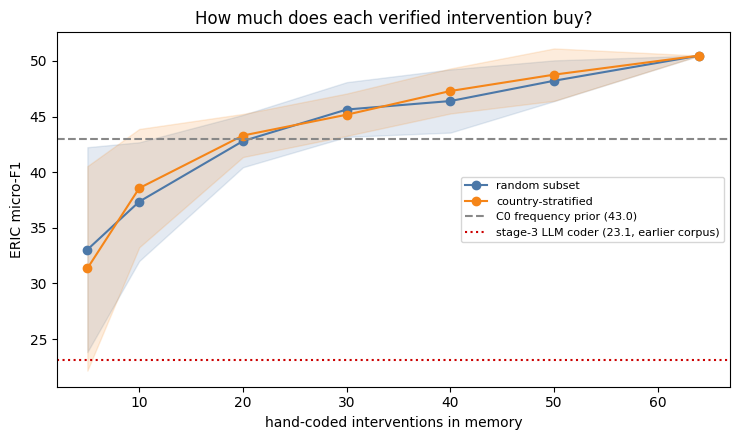

In [8]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for lc, label, colour in ((lc_random, "random subset", "#4C78A8"),
                          (lc_strat, "country-stratified", "#F58518")):
    x = [r["size"] for r in lc]
    y = np.array([r["mean"] for r in lc]) * 100
    sd = np.array([r["std"] for r in lc]) * 100
    ax.plot(x, y, "o-", color=colour, label=label)
    ax.fill_between(x, y - sd, y + sd, color=colour, alpha=0.15)
ax.axhline(c0.F1.max(), ls="--", c="#888", label=f"C0 frequency prior ({c0.F1.max():.1f})")
ax.axhline(23.1, ls=":", c="#C00", label="stage-3 LLM coder (23.1, earlier corpus)")
ax.set_xlabel("hand-coded interventions in memory"); ax.set_ylabel("ERIC micro-F1")
ax.set_title("How much does each verified intervention buy?")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(config.OUTPUTS / "fig_01_learning_curve.png", dpi=150); plt.show()

### How to read this figure — decide before you look

* **still rising at the right edge** → the ceiling is not reached; code more, and the growing
  verified memory in the proposed method is justified.
* **flat after ~30** → the data was never the bottleneck, the method is; effort should go to the
  per-label verdict stage instead.
* **flat from the start, near the C0 line** → kNN is only recovering the label prior and is doing
  no transfer at all. A significant negative result.

Whichever it is, write it down here before moving on.

In [9]:
# scratch: record the reading of the curve
verdict = "TODO — fill in after looking at the figure"
print(verdict)

TODO — fill in after looking at the figure


## What to do next

1. **C2 — SetFit multi-label** on the same train set: the non-LLM control that *does* read text.
2. **Definitions into the shortlist** — retrieval between the intervention and the 73 Powell
   definitions, unioned with C0 and C1 as the candidate set.
3. Only then the document-reading rungs (SOTA-1, SOTA-2), which need the PDFs parsed.